In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import xgboost as xgb
from lightgbm import LGBMRegressor

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
df = pd.read_csv('dhaka_dengue_weather_final.csv')

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df = df[df['date'].dt.year < 2026].reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range  : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Target stats:\n{df['dengue_new_hospitalizations'].describe()}")


Dataset shape: (1727, 43)
Date range  : 2021-04-10 → 2025-12-31
Target stats:
count    1727.000000
mean      157.204980
std       217.083589
min         1.000000
25%        16.000000
50%        71.000000
75%       216.000000
max      1771.000000
Name: dengue_new_hospitalizations, dtype: float64


# Target value is (dengue_new_hospitalizations) — here's why it's the right choice over the other dengue columns:


1. It represents daily new hospitalizations, meaning it's a fresh measurement each day, not accumulated or derived from previous days. This makes it the most direct signal of how bad the outbreak is right now.
2. It's actionable, hospitals and health authorities can use a prediction of tomorrow's new admissions to prepare beds, staff, and supplies.
3. It has a real relationship with weather ,precipitation and humidity from 7–21 days ago directly affect mosquito breeding, which then shows up as new hospitalizations.

# 1. Categorical columns (**dengue_dominant_serotype, dengue_alert_level, season**) get label-encoded into numbers because models can't read strings.

# 2. Rows with missing lag values (the first 21 days, before the lag window fills up) are dropped.


In [ ]:
# Add Target Lags & Momentum (Crucial for outbreak trends)
df['hosp_lag1d'] = df['dengue_new_hospitalizations'].shift(1)
df['hosp_lag7d'] = df['dengue_new_hospitalizations'].shift(7)
# If dengue_7day_avg includes 'today', shift it to prevent data leakage!
df['dengue_7day_avg_yesterday'] = df['dengue_7day_avg'].shift(1)
df['dengue_14day_avg_yesterday'] = df['dengue_14day_avg'].shift(1)
# Drop rows that now have NaNs because of shifting/lags
df = df.dropna()
# Map Alert Level (Ordinal - has a natural ranking)
alert_mapping = {
                 'No Alert' : 0 ,
                 'Normal'   : 1 ,
                 'Watch'    : 2 ,
                 'Alert'    : 3 ,
                 'Moderate' : 4 ,
                 'High'     : 5 ,
                 'Warning'  : 6 ,
                 'Critical' : 7
                 }
df['alert_level_enc'] = df['dengue_alert_level'].map(alert_mapping)
df = pd.get_dummies(df, columns=['season', 'dengue_dominant_serotype'], drop_first=True)
# Cyclical Time Features (replaces raw 'month')
df['month_sin'] = np.sin(2 * np.pi * df['month']/12.0)
df['month_cos'] = np.cos(2 * np.pi * df['month']/12.0)
df['hosp_log'] = np.log1p(df['dengue_new_hospitalizations'])
dummy_cols = [col for col in df.columns if col.startswith('season_') or col.startswith('dengue_dominant_serotype_')]

FEATURE_COLS = [
    # Temporal (Cyclical)
    'month_sin', 'month_cos', 'day_of_year', 'day','year',
    # Temperature (Dropped max/min to reduce redundancy/multicollinearity)
    'temp_mean_c', 'temp_range_c',
    # Humidity & moisture
    'humidity_pct', 'dew_point_c',
    # Precipitation & Wind
    'precipitation_mm', 'wind_speed_kmh', 'pressure_hpa',
    # Solar
    'solar_radiation_mj_m2', 'sunshine_hours',
    # Weather Lag features (mosquito life cycle)
    'precip_lag7d_mm', 'precip_lag14d_mm', 'precip_lag21d_mm',
    'humidity_lag7d_pct', 'humidity_lag14d_pct', 'humidity_lag21d_pct',
    # Target Lags (Infection momentum)
    'hosp_lag1d', 'hosp_lag7d', 'dengue_7day_avg_yesterday', 'dengue_14day_avg_yesterday',
    # Categorical encoded
    'alert_level_enc'
] + dummy_cols

BASE_COLS = [
    'month_sin', 'month_cos', 'day_of_year', 'day','year',
    'hosp_lag1d', 'hosp_lag7d', 'dengue_7day_avg_yesterday','dengue_14day_avg_yesterday',
    'alert_level_enc'
] + dummy_cols

TARGET_RAW = 'dengue_new_hospitalizations'
TARGET     = 'hosp_log'

In [ ]:
df_model = df[FEATURE_COLS + [TARGET, TARGET_RAW, 'date']].dropna().reset_index(drop=True)

X = df_model[FEATURE_COLS]
y = df_model[TARGET]
x_w = df_model[BASE_COLS]
y_RAW = df_model[TARGET_RAW]

print(f"\nModelling dataset : {X.shape[0]} rows × {X.shape[1]} features")
print(f"Target range      : {y_RAW.min()} – {y_RAW.max()}")


Modelling dataset : 1706 rows × 32 features
Target range      : 1 – 1771


# Train/Test Split Splits the data 80% train / 20% test in chronological order — the first 80% of dates go to training, the last 20% to testing

In [ ]:
SPLIT_RATIO = 0.80
split_idx   = int(len(X) * SPLIT_RATIO)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test      = df_model['date'].iloc[split_idx:]

X_train_w, X_test_w= x_w.iloc[:split_idx], x_w.iloc[split_idx:]

y_test_raw  = df_model[TARGET_RAW].iloc[split_idx:]
y_train_raw = df_model[TARGET_RAW].iloc[:split_idx]

print(f"Train : {X_train.shape[0]} rows ({df_model['date'].iloc[0].date()} → {df_model['date'].iloc[split_idx-1].date()})")
print(f"Test  : {X_test.shape[0]}  rows ({df_model['date'].iloc[split_idx].date()} → {df_model['date'].iloc[-1].date()})")

Train : 1364 rows (2021-05-01 → 2025-01-23)
Test  : 342  rows (2025-01-24 → 2025-12-31)


# Train models



In [ ]:
rf_model = RandomForestRegressor(
    n_estimators   = 110,
    max_depth      = None,
    min_samples_leaf = 3,
    max_features   = 'sqrt' ,
    random_state   = 42,
    n_jobs         = -1,
)
gb_model = GradientBoostingRegressor(
    n_estimators   = 110,
    learning_rate  = 0.08,
    max_depth      = 4,
    min_samples_leaf = 3,
    subsample      = 0.8,
    random_state   = 42
)
xgb_model = xgb.XGBRegressor(
    n_estimators= 200,
    learning_rate=0.08,
    max_depth=5,
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1
)
lgbm_model = LGBMRegressor(
    n_estimators = 150,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.8,
    min_child_samples=10,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

In [ ]:
models = {
    "Random Forest"     : rf_model,
    "Gradient Boosting" : gb_model,
    "LGBMRegressor"     : lgbm_model,
    "XGBoosting"        : xgb_model
}
results = {}
results_w = {}
for model in models.keys():
  models[model].fit(X_train_w, y_train)
  pred_log = models[model].predict(X_test_w)
  pred     = np.expm1(pred_log)
  pred     = np.clip(pred, 0, None)
  mae  = mean_absolute_error(y_test_raw, pred)
  rmse = np.sqrt(mean_squared_error(y_test_raw, pred))
  r2   = r2_score(y_test_raw, pred)
  print("──",model,"without weather data───────────────")
  print(f"  Accuracy: {r2*100:.2f}%")
  print(f"  Error   : {mae:.2f}")
  results_w[model] = {"pred" : pred, "mae" : mae, "rmse" : rmse, "r2" : r2}
print("\n")
for model in models.keys():
  models[model].fit(X_train, y_train)
  pred_log = models[model].predict(X_test)
  pred     = np.expm1(pred_log)
  pred     = np.clip(pred, 0, None)
  mae  = mean_absolute_error(y_test_raw, pred)
  rmse = np.sqrt(mean_squared_error(y_test_raw, pred))
  r2   = r2_score(y_test_raw, pred)
  print("──",model,"───────────────")
  print(f"  Accuracy: {r2*100:.2f}%")
  print(f"  Error   : {mae:.2f}")
  results[model] = {"pred" : pred, "mae" : mae, "rmse" : rmse, "r2" : r2}


── Random Forest without weather data───────────────
  Accuracy: 78.05%
  Error   : 31.28
── Gradient Boosting without weather data───────────────
  Accuracy: 81.23%
  Error   : 30.86
── LGBMRegressor without weather data───────────────
  Accuracy: 80.80%
  Error   : 32.01
── XGBoosting without weather data───────────────
  Accuracy: 79.21%
  Error   : 32.57


── Random Forest ───────────────
  Accuracy: 74.33%
  Error   : 33.53
── Gradient Boosting ───────────────
  Accuracy: 79.59%
  Error   : 31.72
── LGBMRegressor ───────────────
  Accuracy: 79.78%
  Error   : 31.30
── XGBoosting ───────────────
  Accuracy: 77.45%
  Error   : 32.72


# Cross-Validation
Instead of trusting a single train/test score, this tests both models across 5 different time windows using TimeSeriesSplit. Each fold trains on earlier data and tests on later data. The output gives us a mean R² and a standard deviation  a high standard deviation means the model performs very differently depending on the time period, which is a sign of instability.

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

rf_cv = cross_val_score(rf_model, X, y, cv=tscv, scoring='r2')
gb_cv = cross_val_score(gb_model, X, y, cv=tscv, scoring='r2')
xgb_cv = cross_val_score(xgb_model, X, y, cv=tscv, scoring='r2')
lgbm_cv = cross_val_score(lgbm_model, X, y, cv=tscv, scoring='r2')

print("── Cross-Validation R² (5-fold TimeSeriesSplit) ──")
print(f"  RF  : {rf_cv.round(3)}  →  mean = {rf_cv.mean():.3f} ± {rf_cv.std():.3f}")
print(f"  GB  : {gb_cv.round(3)}  →  mean = {gb_cv.mean():.3f} ± {gb_cv.std():.3f}")
print(f"  LGBM : {lgbm_cv.round(3)}  →  mean = {lgbm_cv.mean():.3f} ± {lgbm_cv.std():.3f}")
print(f"  XGB  : {xgb_cv.round(3)}  →  mean = {xgb_cv.mean():.3f} ± {xgb_cv.std():.3f}")


── Cross-Validation R² (5-fold TimeSeriesSplit) ──
  RF  : [0.795 0.765 0.935 0.922 0.909]  →  mean = 0.865 ± 0.071
  GB  : [0.914 0.89  0.949 0.938 0.93 ]  →  mean = 0.924 ± 0.021
  LGBM : [0.917 0.876 0.948 0.937 0.929]  →  mean = 0.922 ± 0.025
  XGB  : [0.929 0.85  0.95  0.936 0.93 ]  →  mean = 0.919 ± 0.035


# Plot: Predicted vs Actual
Draws a line chart for both models showing how closely the predictions follow the real hospitalization counts over the test period. The shaded area between the actual and predicted lines makes it easy to see where the model struggles, typically at sharp outbreak peaks.

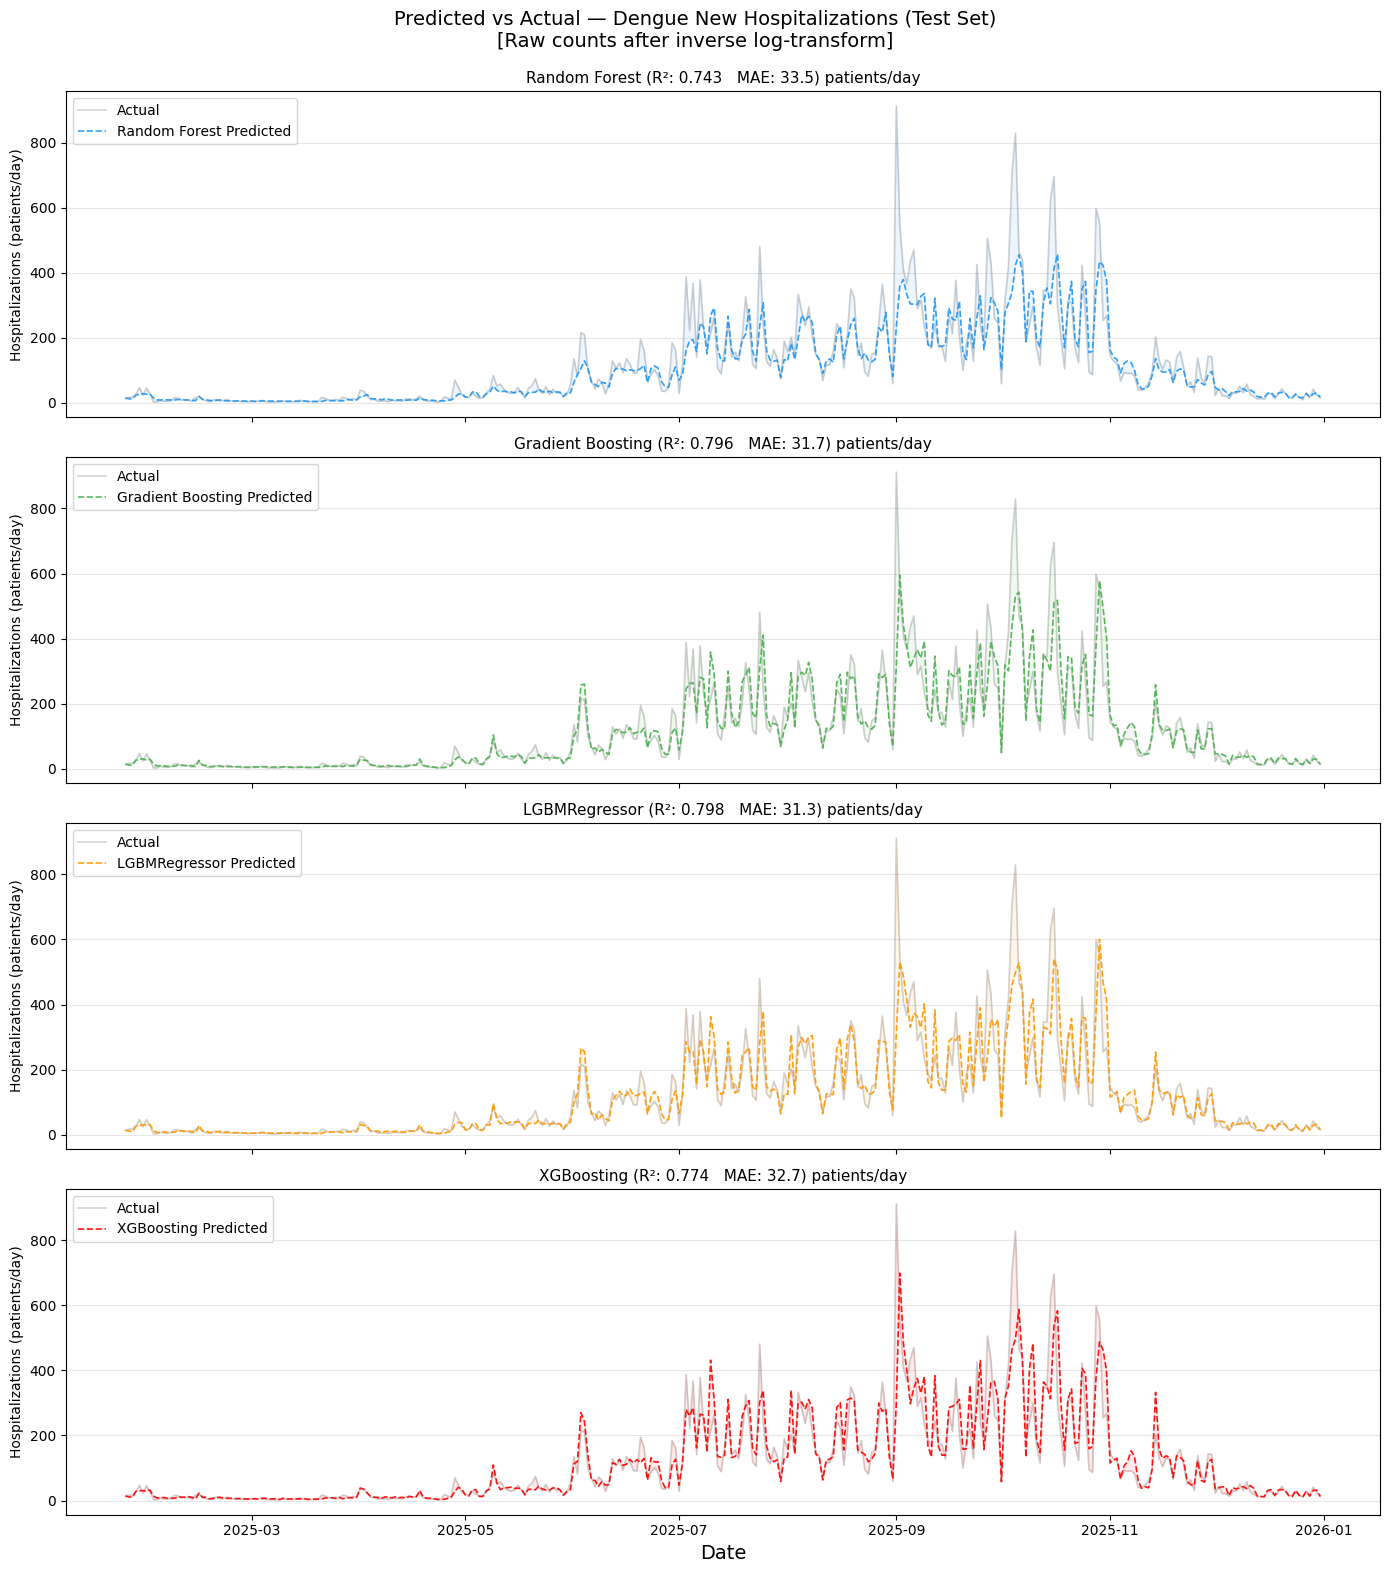

In [ ]:
fig, axes = plt.subplots(len(models), 1, figsize=(14, 16), sharex=True)
fig.suptitle('Predicted vs Actual — Dengue New Hospitalizations (Test Set)\n[Raw counts after inverse log-transform]\n', fontsize=14)
colors = ['#2196F3', '#4CAF50', '#FF9800', '#FF0000']
for ax, color, (model_name, metrics) in zip(axes, colors, results.items()):
    ax.plot(dates_test.values, y_test_raw.values, color='#555', linewidth=1.2, label='Actual', alpha=0.25)
    ax.plot(dates_test, metrics['pred'], label=f'{model_name} Predicted',color=color,  linewidth=1.2, linestyle='--', alpha=0.9)
    ax.fill_between(dates_test.values, y_test_raw.values, metrics['pred'], alpha=0.08, color=color)
    ax.set_title(f"{model_name} (R²: {metrics['r2']:.3f}   MAE: {metrics['mae']:.1f}) patients/day", fontsize=11)
    ax.set_ylabel('Hospitalizations (patients/day)')
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
plt.xlabel('Date', fontsize=14)
plt.tight_layout()
plt.show()

# Plot: Feature Importance
Shows which features each model relied on most. The longer the bar, the more that feature influenced predictions. Both models should rank month, day_of_year, and precipitation lag features near the top, confirming that seasonality and the mosquito breeding cycle (which takes 7–21 days after rain) are the dominant signals.

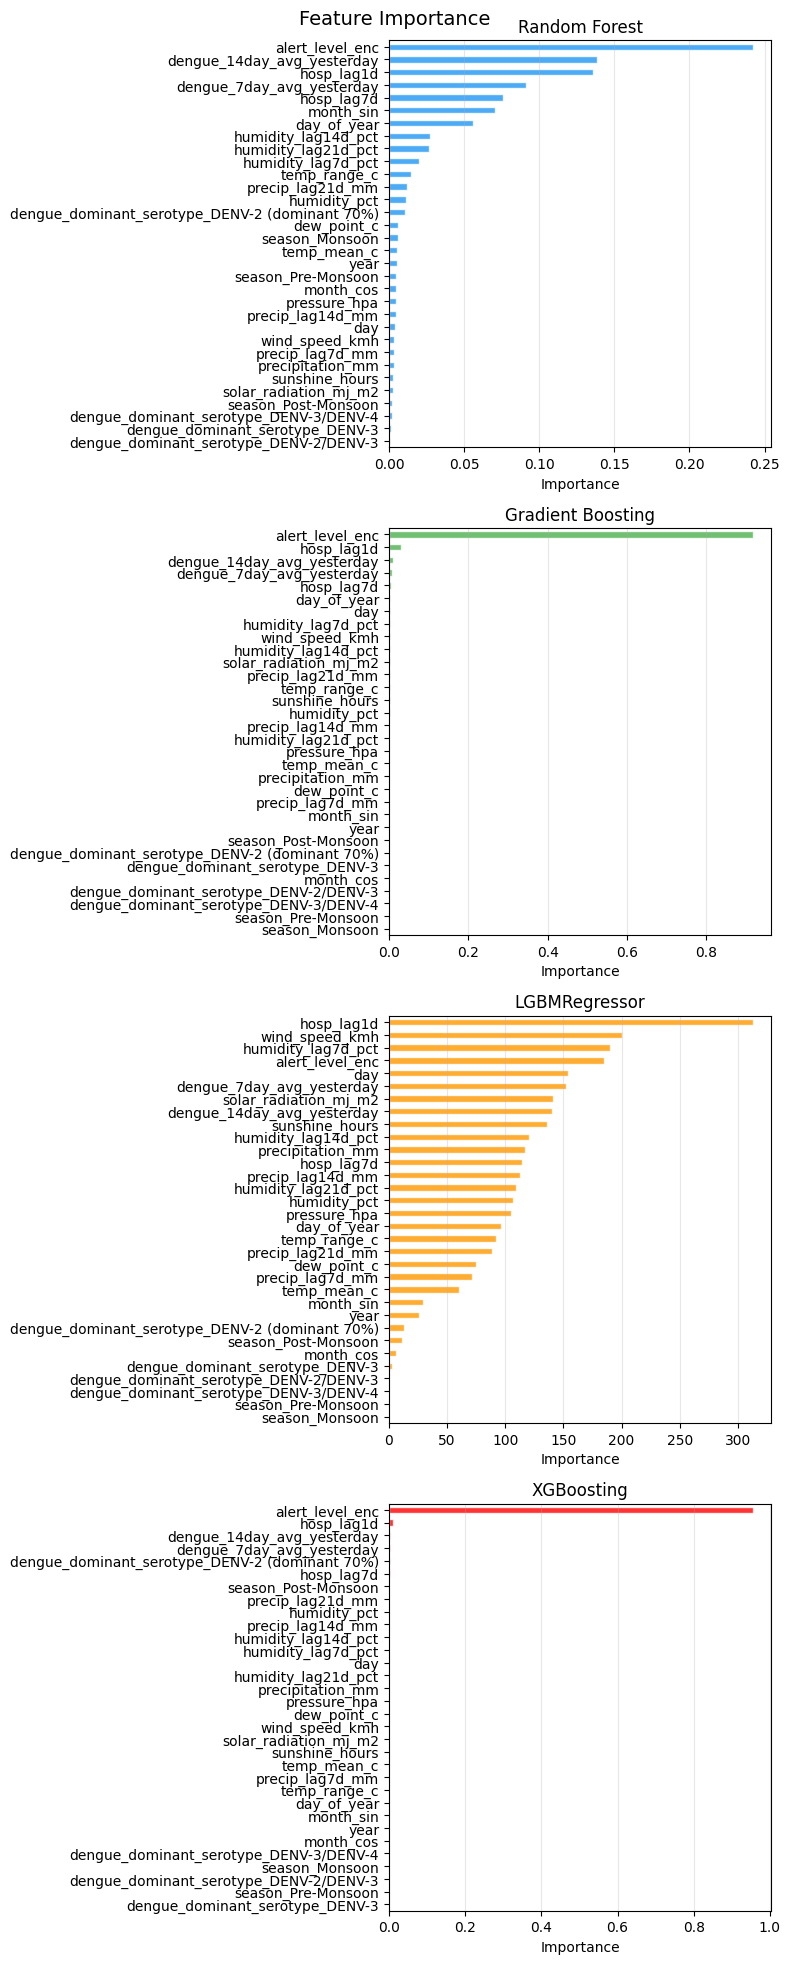

In [ ]:
fig, axes = plt.subplots(len(models), 1, figsize=(8, 20))
fig.suptitle('Feature Importance', fontsize=14)
for ax, color, (model_name, metrics) in zip(axes, colors, results.items()):
    fi = pd.Series(models[model_name].feature_importances_, index=FEATURE_COLS).sort_values()
    fi.plot(kind='barh', ax=ax, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(model_name, fontsize=12)
    ax.set_xlabel('Importance')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot: Scatter (Actual vs Predicted)
Plots each test day as a dot — actual value on the x-axis, predicted on the y-axis. The red dashed diagonal is the "perfect prediction" line. Dots clustered tightly along that line = good model. Dots fanning out at the top right means the model underestimates high-outbreak days, which we will likely see here since extreme peaks are hard to predict from weather alone.

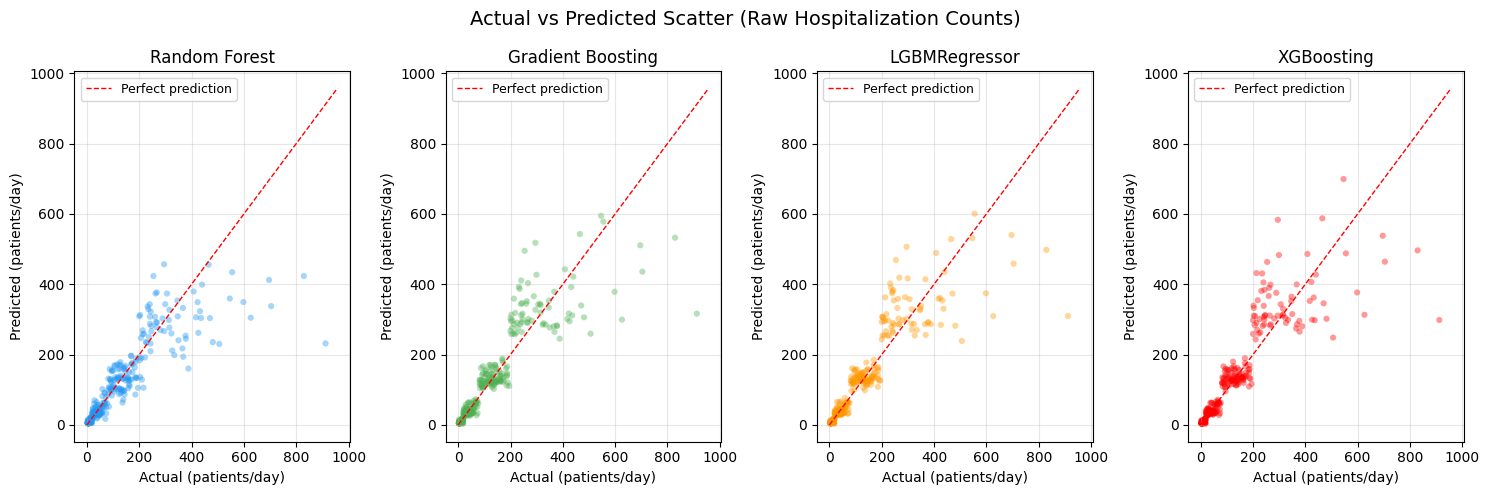

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
fig.suptitle('Actual vs Predicted Scatter (Raw Hospitalization Counts)', fontsize=14)
for ax, color, (model_name, metrics) in zip(axes, colors, results.items()):
    ax.scatter(y_test_raw, metrics['pred'], alpha=0.4, color=color, edgecolors='none', s=20)
    lim = max(y_test_raw.max(), metrics['pred'].max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel('Actual (patients/day)')
    ax.set_ylabel('Predicted (patients/day)')
    ax.set_title(model_name, fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('scatter_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

#Plot: Model Accuracy Comparison
A side-by-side grouped bar chart comparing R², MAE, and RMSE for all four models.
Higher R² = better. Lower MAE/RMSE = better.

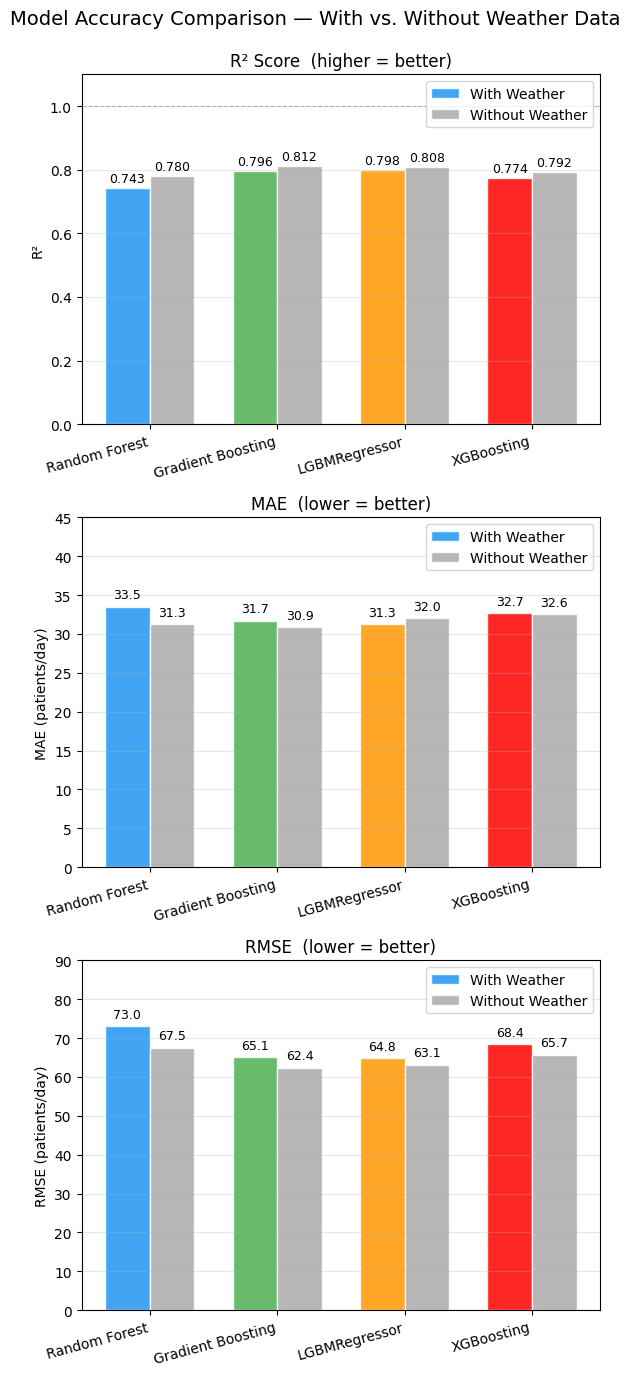

In [ ]:
model_names = list(results.keys())
r2_with  = [results[m]["r2"] for m in model_names]
r2_wo    = [results_w[m]["r2"] for m in model_names]

mae_with = [results[m]["mae"] for m in model_names]
mae_wo   = [results_w[m]["mae"] for m in model_names]

rmse_with= [results[m]["rmse"] for m in model_names]
rmse_wo  = [results_w[m]["rmse"] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

color_wo     = '#AAAAAA'
color_with   = ['#2196F3', '#4CAF50', '#FF9800', '#FF0000']

fig, axes = plt.subplots(3, 1, figsize=(6, 14))
fig.suptitle('Model Accuracy Comparison — With vs. Without Weather Data\n', fontsize=14)
def add_labels(ax, bars, formatting, y_offset):
    for bar in bars:
        val = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, val + y_offset,
                f'{val:{formatting}}', ha='center', va='bottom', fontsize=9)
bars_r2_with = axes[0].bar(x - width/2, r2_with, width, label='With Weather', color=color_with, alpha=0.85, edgecolor='white')
bars_r2_wo   = axes[0].bar(x + width/2, r2_wo,   width, label='Without Weather', color=color_wo, alpha=0.85, edgecolor='white')

axes[0].set_title('R² Score  (higher = better)', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=15, ha='right', fontsize=10)
axes[0].set_ylim(0, 1.1)
axes[0].axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].set_ylabel('R²')
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend(loc='upper right')

add_labels(axes[0], bars_r2_with, '.3f', 0.01)
add_labels(axes[0], bars_r2_wo,   '.3f', 0.01)

bars_mae_with = axes[1].bar(x - width/2, mae_with, width, label='With Weather', color=color_with, alpha=0.85, edgecolor='white')
bars_mae_wo   = axes[1].bar(x + width/2, mae_wo,   width, label='Without Weather', color=color_wo, alpha=0.85, edgecolor='white')

axes[1].set_title('MAE  (lower = better)', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=15, ha='right', fontsize=10)
axes[1].set_ylim(0, 45)
axes[1].set_ylabel('MAE (patients/day)')
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend(loc='upper right')
mae_offset = max(max(mae_with), max(mae_wo)) * 0.02
add_labels(axes[1], bars_mae_with, '.1f', mae_offset)
add_labels(axes[1], bars_mae_wo,   '.1f', mae_offset)
bars_rmse_with = axes[2].bar(x - width/2, rmse_with, width, label='With Weather', color=color_with, alpha=0.85, edgecolor='white')
bars_rmse_wo   = axes[2].bar(x + width/2, rmse_wo,   width, label='Without Weather', color=color_wo, alpha=0.85, edgecolor='white')
axes[2].set_title('RMSE  (lower = better)', fontsize=12)
axes[2].set_xticks(x)
axes[2].set_xticklabels(model_names, rotation=15, ha='right', fontsize=10)
axes[2].set_ylim(0, 90)
axes[2].set_ylabel('RMSE (patients/day)')
axes[2].grid(axis='y', alpha=0.3)
axes[2].legend(loc='upper right')
rmse_offset = max(max(rmse_with), max(rmse_wo)) * 0.02
add_labels(axes[2], bars_rmse_with, '.1f', rmse_offset)
add_labels(axes[2], bars_rmse_wo,   '.1f', rmse_offset)
plt.tight_layout()
plt.savefig('accuracy_comparison_weather_vs_no_weather.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot: Residuals
Plots the error (actual minus predicted) against the predicted value. Ideally the dots should scatter randomly around zero with no pattern.

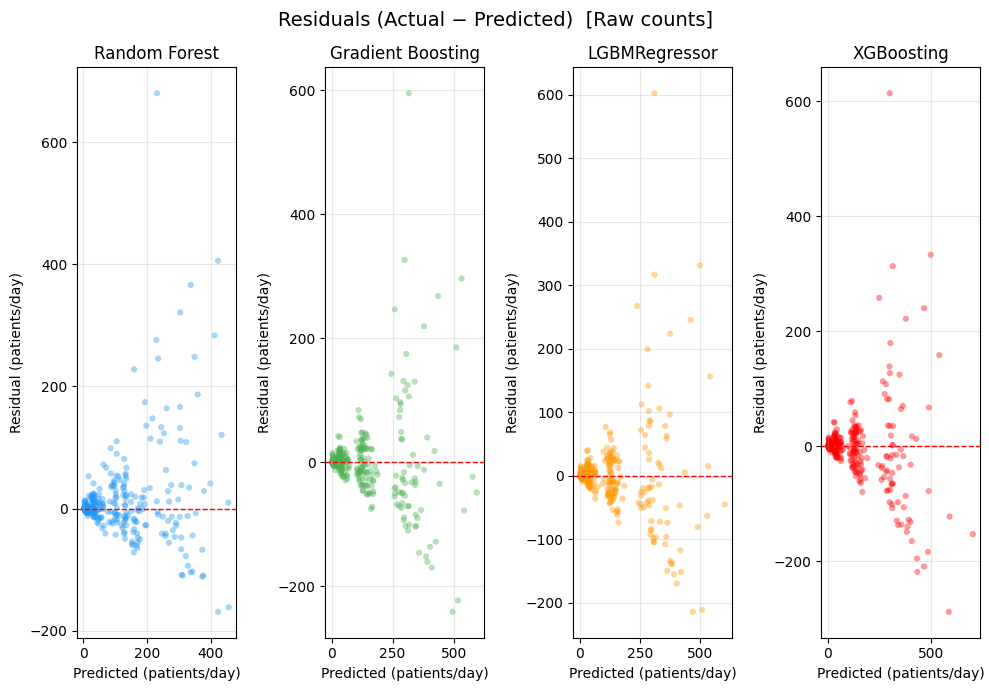

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(10, 7))
fig.suptitle('Residuals (Actual − Predicted)  [Raw counts]', fontsize=14)
for ax, color, (model_name, metrics) in zip(axes, colors, results.items()):
    residuals = y_test_raw.values - metrics["pred"]
    ax.scatter(metrics["pred"], residuals, alpha=0.4, color=color, edgecolors='none', s=20)
    ax.axhline(0, color='red', linewidth=1, linestyle='--')
    ax.set_xlabel('Predicted (patients/day)')
    ax.set_ylabel('Residual (patients/day)')
    ax.set_title(model_name, fontsize=12)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('residuals.png', dpi=150, bbox_inches='tight')
plt.show()

#Plot: ROC Curve Comparison
ROC curves require binary labels, so we convert the regression problem into a
classification task: a day is labeled "high outbreak" (1) if its actual
hospitalization count exceeds the 75th percentile of the TRAINING set.
Each model's predicted score = its predicted raw hospitalization count.


ROC outbreak threshold (75th pct of train set): 234.0 patients/day
High-outbreak days in test set: 57 / 342


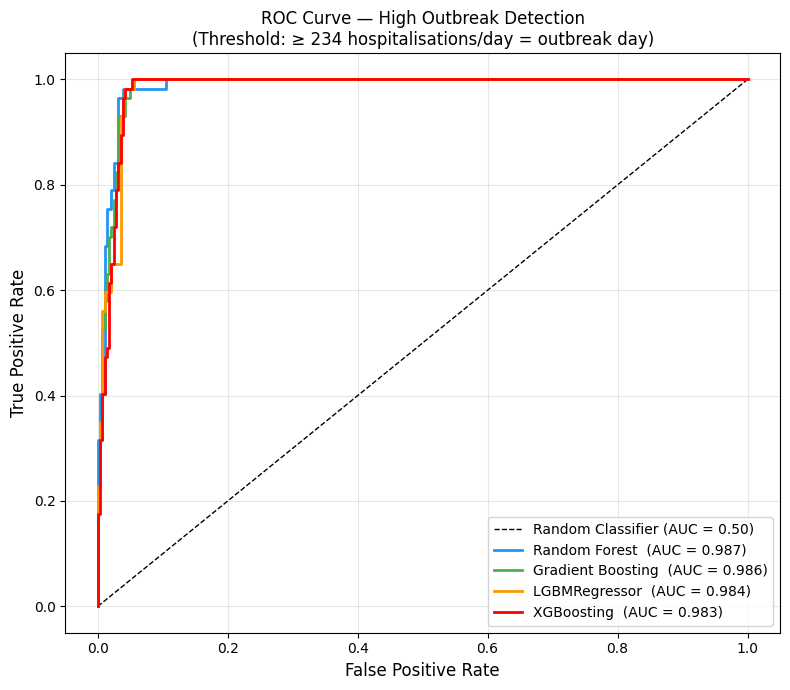

In [ ]:
from sklearn.metrics import roc_curve, auc

# Threshold: 75th percentile of RAW training target
OUTBREAK_THRESHOLD = np.percentile(y_train_raw, 75)
print(f"\nROC outbreak threshold (75th pct of train set): {OUTBREAK_THRESHOLD:.1f} patients/day")

# Binary labels for test set: 1 = high outbreak day, 0 = normal day
y_binary = (y_test_raw.values >= OUTBREAK_THRESHOLD).astype(int)
print(f"High-outbreak days in test set: {y_binary.sum()} / {len(y_binary)}")

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.50)')
for color, (model_name, metrics) in zip(colors, results.items()):
    fpr, tpr, _ = roc_curve(y_binary, metrics['pred'])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, linestyle='-' ,label=f'{model_name}  (AUC = {roc_auc:.3f})')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(
    f'ROC Curve — High Outbreak Detection\n'
    f'(Threshold: ≥ {OUTBREAK_THRESHOLD:.0f} hospitalisations/day = outbreak day)',
    fontsize=12
)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary Table
Prints a clean comparison table of MAE, RMSE, R², and cross-validation scores side by side. Use this to decide which model to go with — lower MAE/RMSE and higher R² is better.

In [ ]:
summary = pd.DataFrame({
    'Model'  : ['Random Forest', 'Gradient Boosting', 'LGBM','XGBoost'],
    'MAE'    : mae_with,
    'RMSE'   : rmse_with,
    'R²'     : r2_with,
    'CV R² (mean)': [rf_cv.mean(), gb_cv.mean(), lgbm_cv.mean(), xgb_cv.mean()],
    'CV R² (std)' : [rf_cv.std(),  gb_cv.std(),  lgbm_cv.std(), xgb_cv.std()],
}).round(4)

print('\n── Final Model Comparison ──────────────────────────────')
print(summary.to_string(index=False))


── Final Model Comparison ──────────────────────────────
            Model     MAE    RMSE     R²  CV R² (mean)  CV R² (std)
    Random Forest 33.5313 72.9892 0.7433        0.8654       0.0706
Gradient Boosting 31.7173 65.0876 0.7959        0.9244       0.0207
             LGBM 31.2979 64.7842 0.7978        0.9216       0.0250
          XGBoost 32.7225 68.4177 0.7745        0.9190       0.0353


In [ ]:

results_df = pd.DataFrame({
    'date'          : dates_test.values,
    'actual'        : y_test.values,
    'rf_predicted'  : results['Random Forest']['pred'].round(1),
    'gb_predicted'  : results['Gradient Boosting']['pred'].round(1),
    'lgbm_predicted': results["LGBMRegressor"  ]['pred'].round(1),
    'xgb_predicted' : results["XGBoosting" ]['pred'].round(1),
    'rf_error'      : (y_test.values - results['Random Forest']['pred']).round(1),
    'gb_error'      : (y_test.values - results['Gradient Boosting']['pred']).round(1),
    'lgbm_error'    : (y_test.values - results["LGBMRegressor"  ]['pred']).round(1),
    'xgb_error'     : (y_test.values - results["XGBoosting" ]['pred']).round(1)
})
results_df.to_csv('dengue_predictions.csv', index=False)
print('Saved → dengue_predictions.csv')

Saved → dengue_predictions.csv
